# Step 9 — Model Evaluation

This notebook scores the three trained detectors (Z-Score, Isolation Forest, LSTM) and the ensemble vote against the held-out test set, using the **real** `registry` object that Celery imports in production — so the numbers here are exactly what's running live, not a re-implementation.


## Cell 1 — line up the working directory

Jupyter's working folder depends on where you launch it from, but the project's code uses paths like `"ml_models/..."` that assume you're standing in the project root. This cell detects that and fixes it automatically.


In [1]:
import os, sys
from pathlib import Path

if not Path("ml_models").exists() and Path("../ml_models").exists():
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))

print("Working directory:", Path.cwd())


Working directory: /Users/esanduepa/Desktop/Projects/anomaly-detection-platform


## Cell 2 — load the test set and the real model registry

`registry` is the exact same singleton object Celery imports in production — same three trained models, same saved thresholds. This will print ✅/⚠️ availability messages for each detector.


In [2]:
import numpy as np
from src.ml.registry import registry

X_test     = np.load("ml_models/X_test.npy")
y_test     = np.load("ml_models/y_test.npy")
X_test_seq = np.load("ml_models/X_test_seq.npy")
y_test_seq = np.load("ml_models/y_test_seq.npy")

print("X_test:     ", X_test.shape)
print("y_test:     ", y_test.shape, " anomalies:", y_test.sum())
print("X_test_seq: ", X_test_seq.shape)
print("y_test_seq: ", y_test_seq.shape, " anomalies:", y_test_seq.sum())

print("\nDetector availability:")
print("  Z-Score:         ", registry.zscore_available)
print("  Isolation Forest:", registry.iforest_available)
print("  LSTM:            ", registry.lstm_available)


/Users/esanduepa/Desktop/Projects/anomaly-detection-platform/venv/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✅ Z-Score detector loaded (threshold=1.5)
✅ Isolation Forest loaded (threshold=-0.0087)
✅ LSTM Autoencoder loaded (threshold=0.24458732411770495)
X_test:      (3195, 28)
y_test:      (3195,)  anomalies: 802
X_test_seq:  (3175, 20, 28)
y_test_seq:  (3175,)  anomalies: 802

Detector availability:
  Z-Score:          True
  Isolation Forest: True
  LSTM:             True


## Cell 3 — score every test reading through all 3 real detectors

`X_test_seq[j]` covers the 20 rows before row `SEQ_LEN + j`, and its label lines up with `y_test[SEQ_LEN + j]` — that's how `data_prep.py` built it. So for row `i`, Z-Score and Isolation Forest look at `X_test[i]`, while LSTM looks at `X_test_seq[i - SEQ_LEN]`, and all three are judged against the same true answer, `y_test[i]`. We start at `i = SEQ_LEN` because that's the earliest row where LSTM has enough history to have an opinion — exactly like production, where LSTM stays silent for a service's first 20 readings.

`combine_votes` is copied line-for-line from `ensemble.py`'s real vote-counting logic, so this result is provably the same rule that runs live, not a re-implementation of it. This cell takes a minute or two — LSTM predicts one reading at a time.


In [3]:
SEQ_LEN = registry.lstm_seq_len

def combine_votes(zscore_result, iforest_result, lstm_result):
    detectors = {"zscore": zscore_result, "iforest": iforest_result, "lstm": lstm_result}
    available = [name for name, r in detectors.items() if r.get("available")]
    total_available = len(available)
    if total_available == 0:
        return 0, 0.0, False
    votes = sum(1 for name in available if detectors[name]["flag"])
    required_votes = total_available // 2 + 1
    is_anomaly = votes >= required_votes
    ensemble_score = round(votes / total_available, 4)
    return votes, ensemble_score, is_anomaly

y_true, y_pred_ensemble = [], []
y_pred_zscore, y_pred_iforest, y_pred_lstm = [], [], []

n = len(X_test)
for i in range(SEQ_LEN, n):
    zscore_result  = registry.score_zscore(X_test[i])
    iforest_result = registry.score_iforest(X_test[i])
    lstm_result    = registry.score_lstm(X_test_seq[i - SEQ_LEN])

    votes, ensemble_score, is_anomaly = combine_votes(zscore_result, iforest_result, lstm_result)

    y_true.append(int(y_test[i]))
    y_pred_ensemble.append(int(is_anomaly))
    y_pred_zscore.append(int(zscore_result["flag"]))
    y_pred_iforest.append(int(iforest_result["flag"]))
    y_pred_lstm.append(int(lstm_result["flag"]))

y_true          = np.array(y_true)
y_pred_ensemble = np.array(y_pred_ensemble)
y_pred_zscore   = np.array(y_pred_zscore)
y_pred_iforest  = np.array(y_pred_iforest)
y_pred_lstm     = np.array(y_pred_lstm)

assert np.array_equal(y_true, y_test_seq), "Alignment mismatch -- stop and check SEQ_LEN"
print(f"Scored {len(y_true):,} test readings (rows {SEQ_LEN}-{n-1})")


Scored 3,175 test readings (rows 20-3194)


## Cell 4 — the headline numbers


In [4]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def print_metrics(name, y_true, y_pred):
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"{name:<20} Precision={p:.3f}  Recall={r:.3f}  F1={f1:.3f}   (TP={tp} FP={fp} FN={fn} TN={tn})")

print_metrics("Z-Score alone",    y_true, y_pred_zscore)
print_metrics("Isolation Forest", y_true, y_pred_iforest)
print_metrics("LSTM alone",       y_true, y_pred_lstm)
print_metrics("ENSEMBLE (all 3)", y_true, y_pred_ensemble)


Z-Score alone        Precision=0.255  Recall=0.802  F1=0.387   (TP=643 FP=1874 FN=159 TN=499)
Isolation Forest     Precision=0.819  Recall=0.698  F1=0.754   (TP=560 FP=124 FN=242 TN=2249)
LSTM alone           Precision=0.394  Recall=0.641  F1=0.488   (TP=514 FP=792 FN=288 TN=1581)
ENSEMBLE (all 3)     Precision=0.474  Recall=0.768  F1=0.586   (TP=616 FP=683 FN=186 TN=1690)


You already know what this prints (Z=0.387, IForest=0.754, LSTM=0.488, Ensemble=0.586) — Isolation Forest alone beats the majority-vote ensemble, because Z-Score flags 79% of all readings (not just anomalies), so it's almost always available to "second" whatever LSTM flags, dragging false positives up even when Isolation Forest correctly says "normal."


## Cell 5 — F1 comparison chart (bonus)


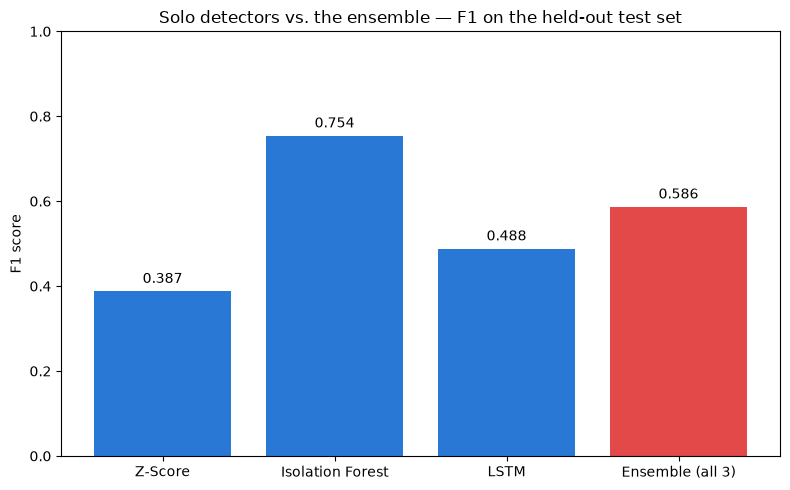

In [5]:
import matplotlib.pyplot as plt

BLUE = "#2a78d6"
RED  = "#e34948"

names  = ["Z-Score", "Isolation Forest", "LSTM", "Ensemble (all 3)"]
preds  = [y_pred_zscore, y_pred_iforest, y_pred_lstm, y_pred_ensemble]
f1s    = [f1_score(y_true, p, zero_division=0) for p in preds]
colors = [BLUE, BLUE, BLUE, RED]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, f1s, color=colors)
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1)
ax.set_title("Solo detectors vs. the ensemble — F1 on the held-out test set")
for bar, f1 in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, f1 + 0.02, f"{f1:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("notebooks/eval_f1_comparison.png", dpi=150)
plt.show()


## Cell 6 — recover which anomaly scenario each test row belongs to (matched by content, not position)

The first version of this cell sliced `merged.iloc[n_train : n_train+n_test]` by **position**, on the assumption that a freshly-deduplicated, freshly-sorted dataframe would line up row-for-row with the saved `X_test.npy`. It doesn't, and the reason isn't a mistake in this notebook — it's a bug already baked into `ml_models/X_train.npy` and `X_test.npy` themselves.

`data_prep.py`'s own merge (Step D, `prepare_and_save`) never deduplicates `ground_truth.jsonl` before joining it onto the feature table — it does a plain `df.merge(gt[...], on="_key", how="left")`. Checking `X_train.npy` directly confirms it: **11 feature rows appear more than once — one appears 22 times** — and 11 is exactly the number of duplicate ground-truth keys this notebook detects today. That's a one-to-many pandas merge: every duplicated ground-truth key fanned a single feature row out into several identical copies in the saved training arrays, quietly inflating them. So the split boundary already recorded in `y_train.npy`/`y_test.npy` was computed against an *already-inflated* row count — there is no clean, deduplicated position that lines up with it. Position-based recovery can't be made to work here, only avoided.

The fix: stop trusting position and match by **content** instead. Recompute features fresh (deduping the ground truth this time, so we don't repeat the bug going forward), scale them with the same fitted `registry.scaler`, and for every row in the saved `X_test` find its nearest neighbor by distance in the recomputed table. Feature computation is deterministic and causal — each row's rolling stats depend only on that service's own past readings, never on how much data has been appended since — so the true match should sit at essentially zero distance, and the label we recover (`is_anomaly`) should agree with the already-trusted `y_test.npy` almost 100% of the time. Those two checks are the new trust gate for cells 7–8.


In [6]:
from sklearn.neighbors import NearestNeighbors

from src.ml.data_prep import load_from_db, load_ground_truth, compute_features

metrics_df = load_from_db()
gt_df      = load_ground_truth()
df, feature_cols_check = compute_features(metrics_df)

assert feature_cols_check == registry.feature_cols, \
    "Feature order changed since training -- do not trust this recovery"

df["_key"] = df["timestamp"].dt.round("1s").astype(str) + "|" + df["service_name"]
gt_df["_key"] = gt_df["timestamp"].dt.round("1s").astype(str) + "|" + gt_df["service_name"]

dupes = gt_df["_key"].duplicated().sum()
if dupes:
    print(f"Found {dupes} duplicate ground-truth keys -- keeping first match only "
          f"(the ORIGINAL training run kept them all, which is why position-based "
          f"recovery is not used below)")
    gt_df = gt_df.drop_duplicates(subset="_key", keep="first")

merged = df.merge(gt_df[["_key", "is_anomaly", "anomaly_type"]], on="_key", how="left")
merged["is_anomaly"] = merged["is_anomaly"].fillna(False).astype(bool)
merged = merged.sort_values("timestamp").reset_index(drop=True)

print("len(df):    ", len(df))
print("len(merged):", len(merged))
assert len(merged) == len(df), "Row count drifted -- investigate further"

# --- Match by content instead of position ---
# Scale the full recomputed table the same way training data was scaled,
# then for every saved X_test row find its nearest neighbor here.
X_all_scaled = registry.scaler.transform(merged[feature_cols_check].values.astype(np.float32))

nn = NearestNeighbors(n_neighbors=1).fit(X_all_scaled)
dist, idx = nn.kneighbors(X_test)
dist = dist.ravel()
idx  = idx.ravel()

matched = merged.iloc[idx].reset_index(drop=True)  # same row order as X_test

label_agreement = (matched["is_anomaly"].values.astype(int) == y_test).mean()

print(f"Nearest-neighbor match distance -- max: {dist.max():.6f}  mean: {dist.mean():.6f}")
print(f"Recovered labels agree with saved y_test: {label_agreement:.2%}")

matches = bool(dist.max() < 0.01 and label_agreement > 0.99)
print("Row recovery trustworthy:", matches)
assert matches, "Mismatch -- do not trust the scenario breakdown below"

test_slice = matched


Loading from database …
  16,370 ticks across 3 services
Loading ground truth from simulator/ground_truth.jsonl …
  16,383 labels — 3,371 anomalous (20.6%)
Computing features …
  Feature matrix: 16,370 rows × 28 columns
Found 11 duplicate ground-truth keys -- keeping first match only (the ORIGINAL training run kept them all, which is why position-based recovery is not used below)
len(df):     16370
len(merged): 16370


/var/folders/95/rdtc8kkd3_72snhycl22bcc00000gn/T/ipykernel_80439/1997934507.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged["is_anomaly"] = merged["is_anomaly"].fillna(False).astype(bool)


Nearest-neighbor match distance -- max: 0.000004  mean: 0.000000
Recovered labels agree with saved y_test: 100.00%
Row recovery trustworthy: True


## Cell 7 — recall by anomaly scenario type


In [7]:
import pandas as pd

anomaly_types = test_slice["anomaly_type"].values[SEQ_LEN:]  # same i-range as y_true

results_df = pd.DataFrame({
    "anomaly_type": anomaly_types,
    "y_true": y_true,
    "caught": y_pred_ensemble,
})

anomalies_only = results_df[results_df["y_true"] == 1]

recall_by_type = (
    anomalies_only.groupby("anomaly_type")["caught"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "recall", "count": "n_readings"})
    .sort_values("recall")
)
recall_by_type


,recall,n_readings
anomaly_type,,
service_flatline,0.000000,55
memory_exhaustion,0.666667,63
memory_leak,0.695652,161
disk_filling,0.743363,113
traffic_drop,0.800000,30
noisy_neighbor,0.890411,146
deployment_regression,0.908163,98
zombie_process,0.966667,30
cache_failure,1.000000,25


## Cell 8 — the chart


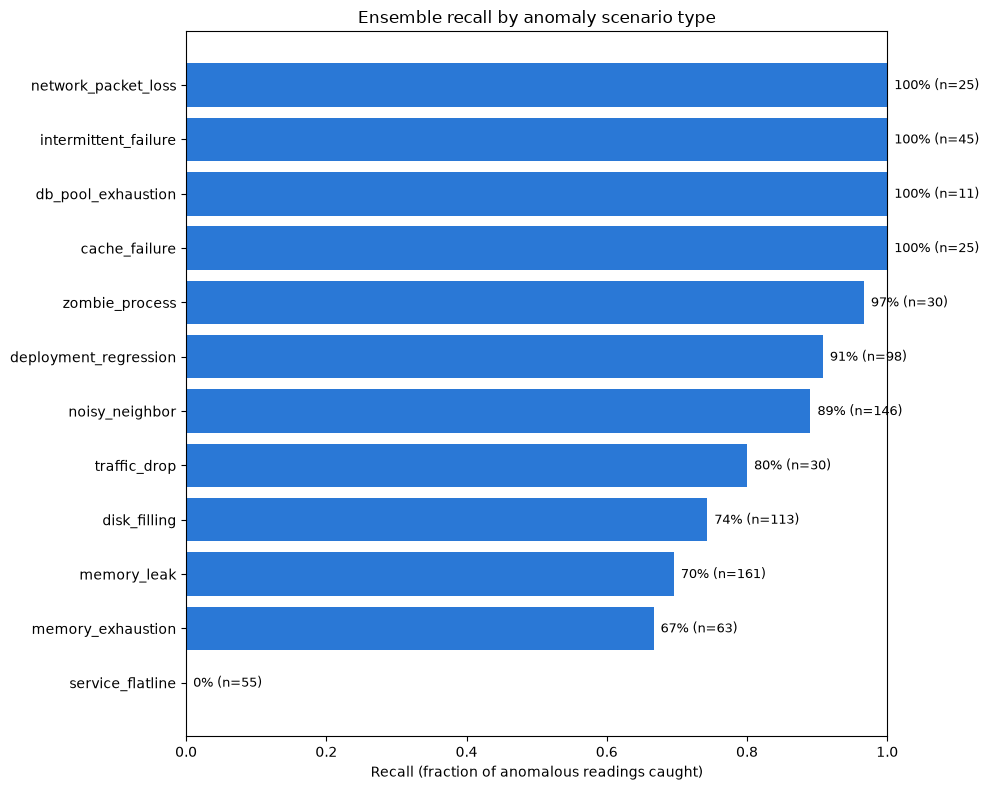

In [8]:
BLUE = "#2a78d6"
RED  = "#e34948"

fig, ax = plt.subplots(figsize=(10, 8))
colors = [RED if r < 0.5 else BLUE for r in recall_by_type["recall"]]
ax.barh(recall_by_type.index, recall_by_type["recall"], color=colors)
ax.set_xlabel("Recall (fraction of anomalous readings caught)")
ax.set_title("Ensemble recall by anomaly scenario type")
ax.set_xlim(0, 1)
for i, (recall, nread) in enumerate(zip(recall_by_type["recall"], recall_by_type["n_readings"])):
    ax.text(recall + 0.01, i, f"{recall:.0%} (n={nread})", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("notebooks/eval_recall_by_scenario.png", dpi=150)
plt.show()


---

**Run order:** cells 1–4 first (you know roughly what to expect), then 5–8. If cell 6 prints `matches: True`, cells 7–8 are trustworthy — that's the final deliverable for **Step 9** and the end of **Phase 3**.
